#### Import All Necessary Libraries

In [1]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

import warnings 
warnings.filterwarnings("ignore")

#### Dataset Loading 

In [4]:
df=pd.read_json("Sarcasm_Headlines_Dataset_v2.json",lines=True)

In [5]:
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [6]:
df.tail()

,is_sarcastic,headline,article_link
28614,1,jews to celebrate rosh hashasha or something,https://www.theonion.com/jews-to-celebrate-ros...
28615,1,internal affairs investigator disappointed con...,https://local.theonion.com/internal-affairs-in...
28616,0,the most beautiful acceptance speech this week...,https://www.huffingtonpost.com/entry/andrew-ah...
28617,1,mars probe destroyed by orbiting spielberg-gat...,https://www.theonion.com/mars-probe-destroyed-...
28618,1,dad clarifies this not a food stop,https://www.theonion.com/dad-clarifies-this-no...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


In [8]:
df.shape

(28619, 3)

In [9]:
df.describe()

,is_sarcastic
count,28619.000000
mean,0.476397
std,0.499451
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
# missing values 
df.isnull().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

In [11]:
# checking duplicated values 
df.duplicated().sum()

np.int64(2)

In [12]:
# drop duplicate  values 
df=df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# check for headline duplicated

In [15]:
df["headline"].duplicated().sum()

np.int64(114)

In [16]:
duplicates = (
    df[df['headline'].duplicated(keep=False)]
    .sort_values('headline')
)

duplicates

,is_sarcastic,headline,article_link
7260,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...
10254,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...
10139,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...
12856,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...
18118,1,"'no way to prevent this,' says only nation whe...",https://www.theonion.com/no-way-to-prevent-thi...
...,...,...,...
24126,1,wolf pack fails to raise orphaned infant,https://www.theonion.com/wolf-pack-fails-to-ra...
14432,1,woman injured in hostile makeover,https://www.theonion.com/woman-injured-in-host...
7456,1,woman injured in hostile makeover,https://local.theonion.com/woman-injured-in-ho...
16249,1,zamboni crime family indicted in ice-shaving s...,https://www.theonion.com/zamboni-crime-family-...


In [17]:
df = df.drop_duplicates(subset="headline", keep="first")

In [18]:
print(df["headline"].duplicated().sum())

0


In [19]:
df.columns

Index(['is_sarcastic', 'headline', 'article_link'], dtype='object')

In [20]:
df.dtypes

is_sarcastic     int64
headline        object
article_link    object
dtype: object

In [21]:
print("Unique values:",df["is_sarcastic"].unique())
print("\n")
print("Number of unique values:",df["is_sarcastic"].nunique())

Unique values: [1 0]


Number of unique values: 2


In [22]:
df["is_sarcastic"].value_counts()

is_sarcastic
0    14951
1    13552
Name: count, dtype: int64

In [23]:
# class percentage distribution

round(df["is_sarcastic"].value_counts(normalize=True)*100,2)

is_sarcastic
0    52.45
1    47.55
Name: proportion, dtype: float64

#### Basic Data Cleaning and Visualization

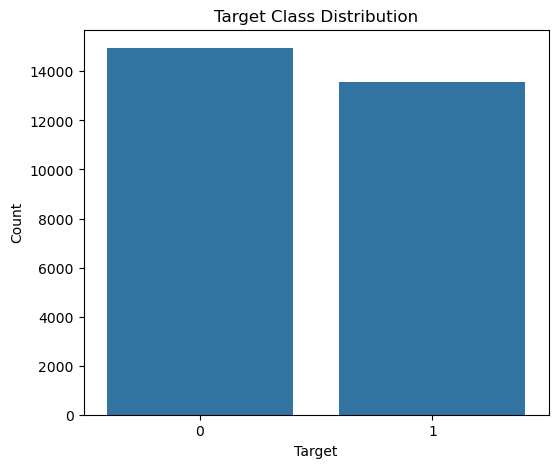

In [24]:
# class distribution 
plt.figure(figsize=(6,5))

sns.countplot(x="is_sarcastic",data=df)
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


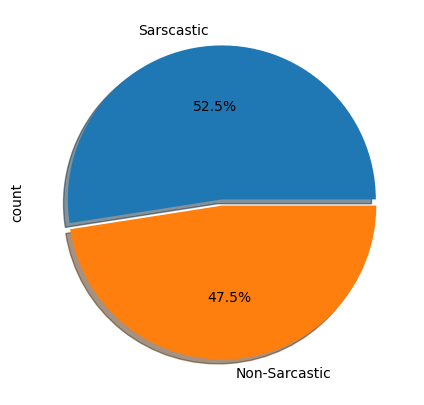

In [25]:
# Pie chart for Percentag Distribution

plt.figure(figsize=(6,5))
df["is_sarcastic"].value_counts().plot(kind='pie', autopct='%1.1f%%',labels=["Sarscastic","Non-Sarcastic"],explode=(0.02,0.02),shadow=True)
plt.show()

In [26]:
#chracter count

df["char_count"]=df["headline"].apply(lambda x:len(x.replace(" ","")))
df[["headline","char_count"]].head(10)

,headline,char_count
0,thirtysomething scientists unveil doomsday clo...,54
1,dem rep. totally nails why congress is falling...,67
2,eat your veggies: 9 deliciously different recipes,43
3,inclement weather prevents liar from getting t...,45
4,mother comes pretty close to using word 'strea...,53
5,my white inheritance,18
6,5 ways to file your taxes with less stress,34
7,richard branson's global-warming donation near...,76
8,shadow government getting too large to meet in...,62
9,lots of parents know this scenario,29


In [27]:
df["char_count"].describe()

count    28503.000000
mean        53.317475
std         17.675694
min          6.000000
25%         42.000000
50%         53.000000
75%         64.000000
max        776.000000
Name: char_count, dtype: float64

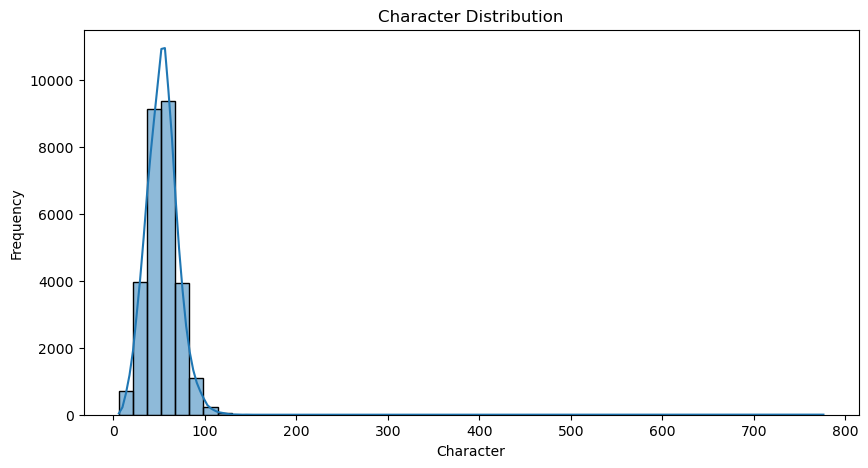

In [28]:
#histogram
plt.figure(figsize=(10,5))

sns.histplot(df["char_count"],bins=50,kde=True)
plt.title("Character Distribution")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.show()

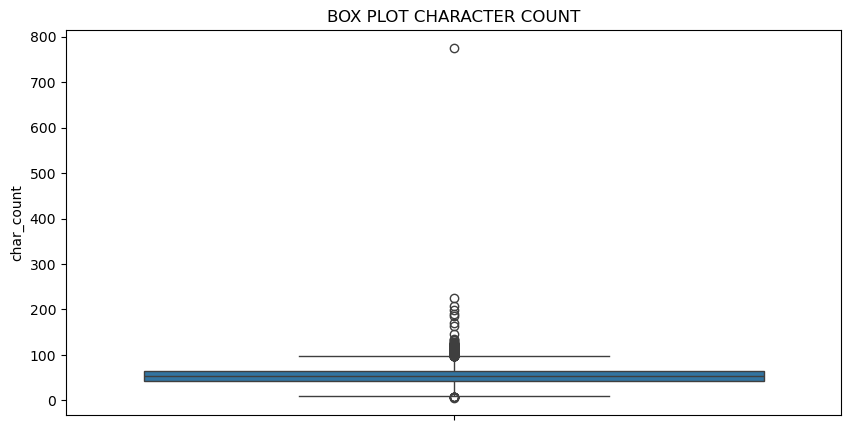

In [32]:
# boxplot 
plt.figure(figsize=(10,5))
sns.boxplot(df["char_count"])
plt.title("BOX PLOT CHARACTER COUNT")
plt.show()

In [33]:
#WORD COUNT
df["word_count"]=df["headline"].apply(lambda x:len(x.split()))
df[["headline","char_count","word_count"]].head()

,headline,char_count,word_count
0,thirtysomething scientists unveil doomsday clo...,54,8
1,dem rep. totally nails why congress is falling...,67,13
2,eat your veggies: 9 deliciously different recipes,43,7
3,inclement weather prevents liar from getting t...,45,8
4,mother comes pretty close to using word 'strea...,53,9


In [34]:
df["word_count"].describe()

count    28503.000000
mean        10.060871
std          3.385275
min          2.000000
25%          8.000000
50%         10.000000
75%         12.000000
max        151.000000
Name: word_count, dtype: float64

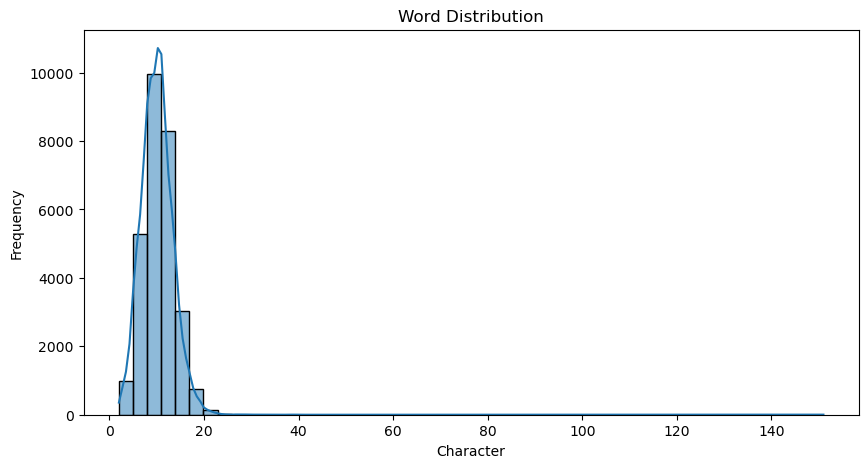

In [36]:
#histogram
plt.figure(figsize=(10,5))

sns.histplot(df["word_count"],bins=50,kde=True)
plt.title("Word Distribution")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.show()

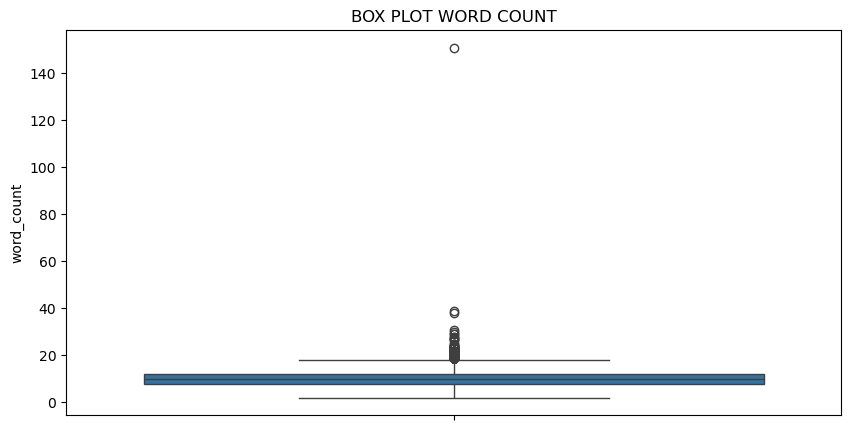

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(df["word_count"])
plt.title("BOX PLOT WORD COUNT")
plt.show()

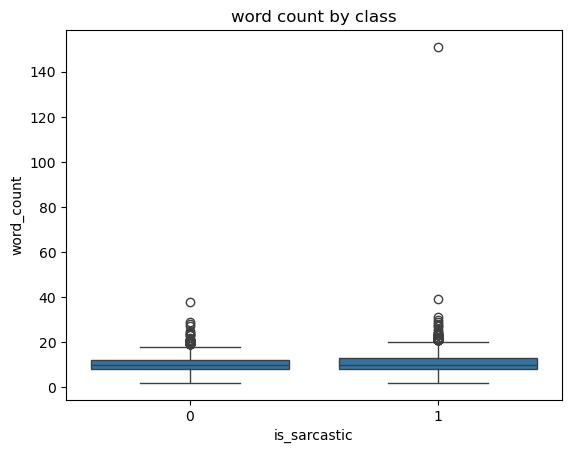

In [38]:
# COMPARE WORD COUNT BY CLASS

sns.boxplot(x="is_sarcastic",y="word_count",data=df)
plt.title("word count by class")
plt.show()

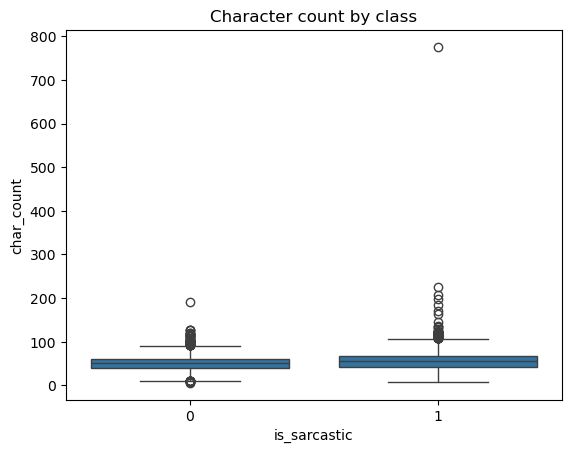

In [39]:
# COMPARE CHARACTER COUNT BY CLASS

sns.boxplot(x="is_sarcastic",y="char_count",data=df)
plt.title("Character count by class")
plt.show()

In [40]:
# Average word count 
df.groupby("is_sarcastic")["word_count"].mean()

is_sarcastic
0     9.824360
1    10.321798
Name: word_count, dtype: float64

In [41]:
#Average Charcater count
df.groupby("is_sarcastic")["char_count"].mean()

is_sarcastic
0    50.788041
1    56.108028
Name: char_count, dtype: float64

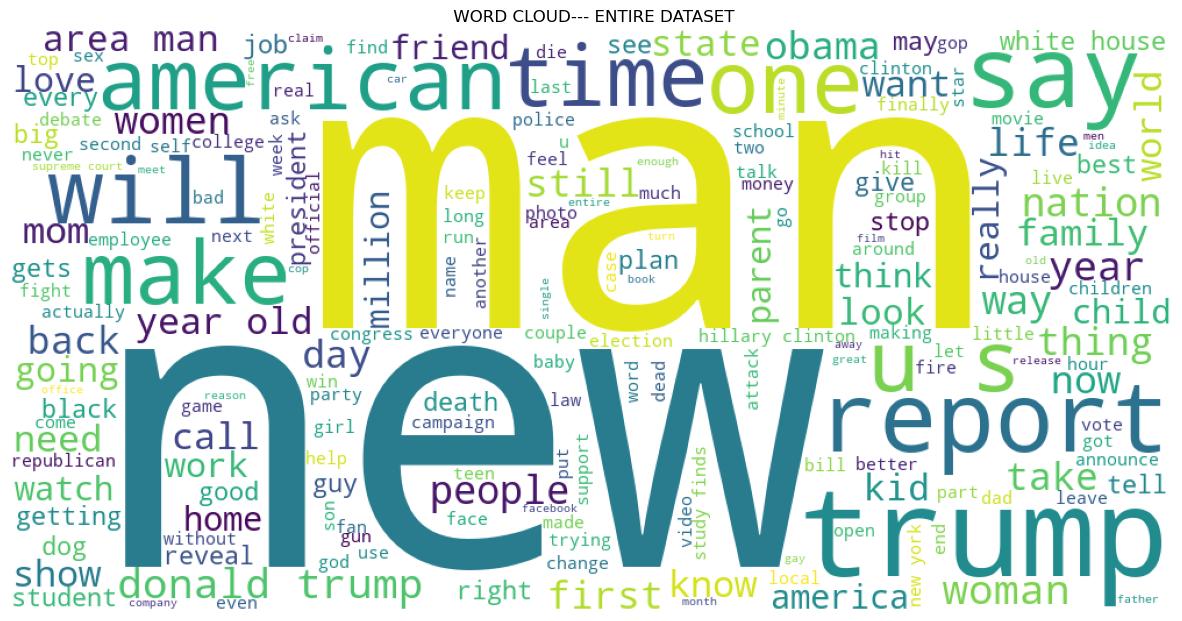

In [42]:
# WORD CLOUD ENTIRE DATASET

text=" ".join(df["headline"])

wordcloud=WordCloud(width=1000,height=500,background_color='white').generate(text)
plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title(" WORD CLOUD--- ENTIRE DATASET")
plt.show()

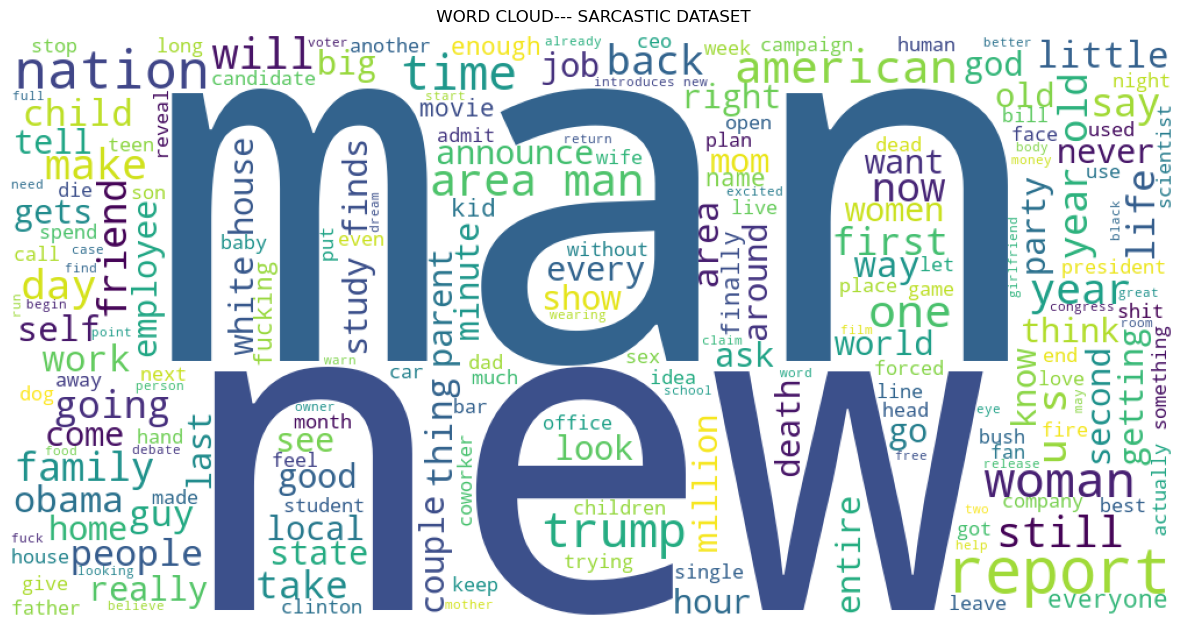

In [43]:
# WORD CLOUD WITH SARCASTIC HEADLINE

sarcastic=" ".join(df[df["is_sarcastic"]==1]["headline"])
wordcloud=WordCloud(width=1000,height=500,background_color='white').generate(sarcastic)
plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title(" WORD CLOUD--- SARCASTIC DATASET",pad=10)
plt.show()

In [38]:
# WORD CLOUD - NON SARCASTIC HEADLINE 

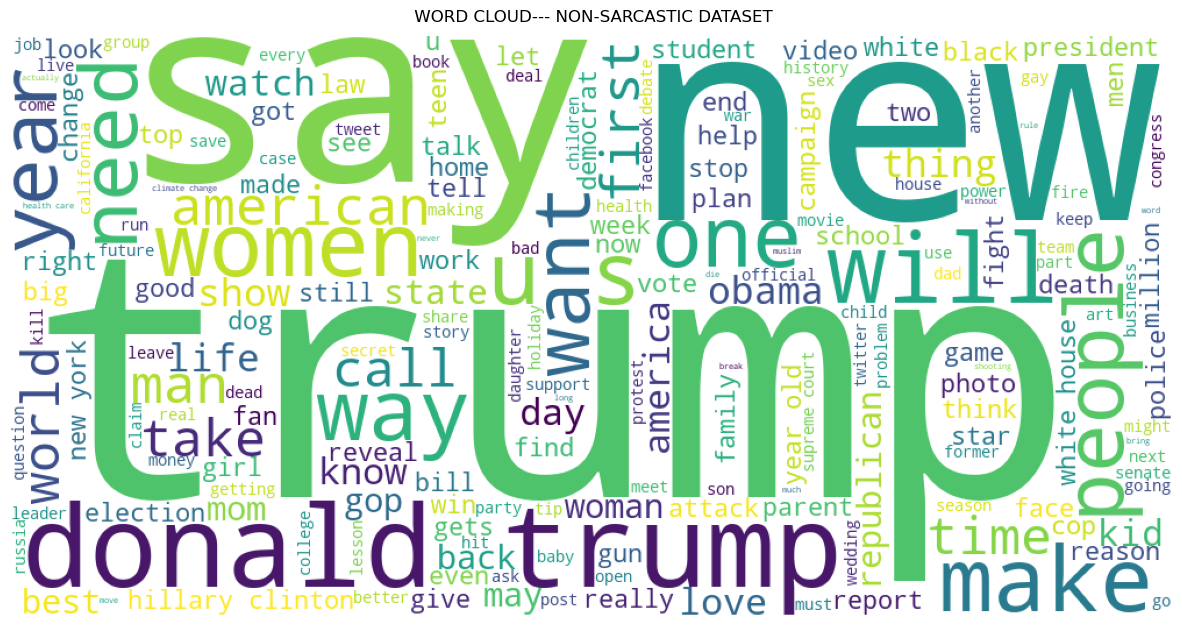

In [39]:
non_sarcastic=" ".join(df[df["is_sarcastic"]==0]["headline"])
wordcloud=WordCloud(width=1000,height=500,background_color='white').generate(non_sarcastic)
plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title(" WORD CLOUD--- NON-SARCASTIC DATASET",pad=10)
plt.show()

In [40]:
# Frequent Words 

In [44]:
all_words = " ".join(df['headline']).lower().split()

word_freq = Counter(all_words)

top20 = word_freq.most_common(20)

top20
                   

[('to', 9018),
 ('of', 6246),
 ('the', 5254),
 ('in', 4515),
 ('for', 3610),
 ('a', 3061),
 ('on', 2600),
 ('and', 1949),
 ('with', 1946),
 ('is', 1695),
 ('new', 1634),
 ('man', 1341),
 ('at', 1314),
 ('from', 1305),
 ('trump', 1284),
 ('about', 1125),
 ('by', 1035),
 ('after', 1001),
 ('you', 961),
 ('be', 909)]

In [45]:
top20_df = pd.DataFrame(
    top20,
    columns=['Word','Frequency']
)

top20_df

,Word,Frequency
0,to,9018
1,of,6246
2,the,5254
3,in,4515
4,for,3610
5,a,3061
6,on,2600
7,and,1949
8,with,1946
9,is,1695


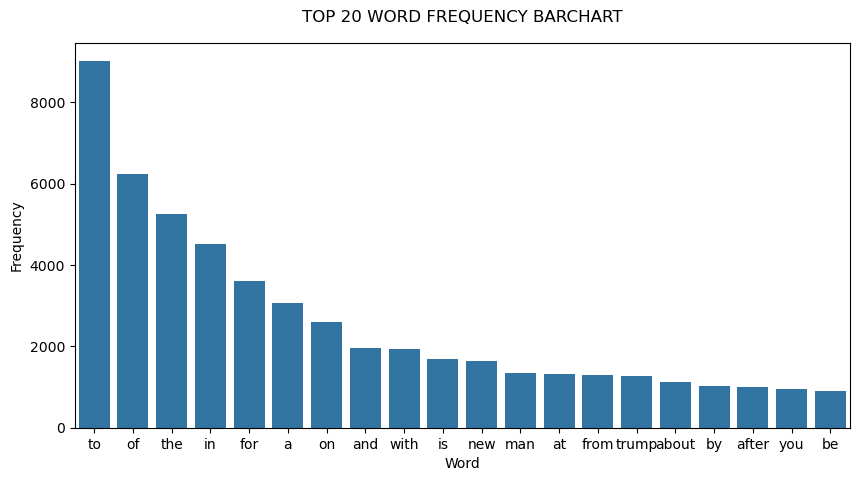

In [47]:
#plotting top 20 words

plt.figure(figsize=(10,5))

sns.barplot(data=top20_df,x='Word',y='Frequency')
plt.title("TOP 20 WORD FREQUENCY BARCHART",pad=15)
plt.show()

In [48]:
# top 20 sarcastic only

sar=" ".join(df[df["is_sarcastic"]==1]['headline']).lower().split()

sar_count=Counter(sar)

sar_df=pd.DataFrame(sar_count.most_common(20),columns=["Word","Frequency"])
sar_df

,Word,Frequency
0,to,4955
1,of,3785
2,in,2098
3,for,1730
4,on,1283
5,man,1133
6,with,1003
7,new,970
8,by,730
9,the,683


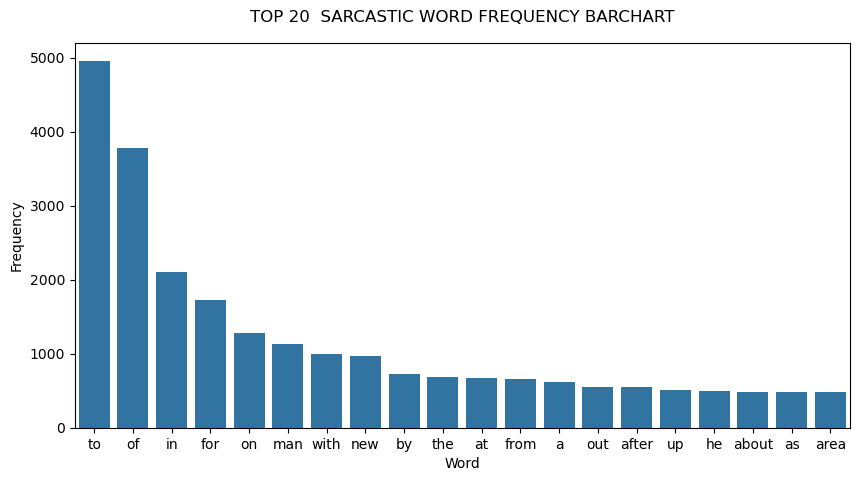

In [49]:
#plotting top 20 words sarcastic word 

plt.figure(figsize=(10,5))

sns.barplot(data=sar_df,x='Word',y='Frequency')
plt.title("TOP 20  SARCASTIC WORD FREQUENCY BARCHART",pad=15)
plt.show()

In [50]:
# top 20 non sarcastic word 

no_sar=" ".join(df[df["is_sarcastic"]==0]["headline"]).lower().split()

no_sar_count=Counter(no_sar)

no_sar_df=pd.DataFrame(no_sar_count.most_common(20),columns=["Word","Frequency"])
no_sar_df

,Word,Frequency
0,the,4571
1,to,4063
2,of,2461
3,a,2443
4,in,2417
5,for,1880
6,and,1630
7,is,1494
8,on,1317
9,trump,957


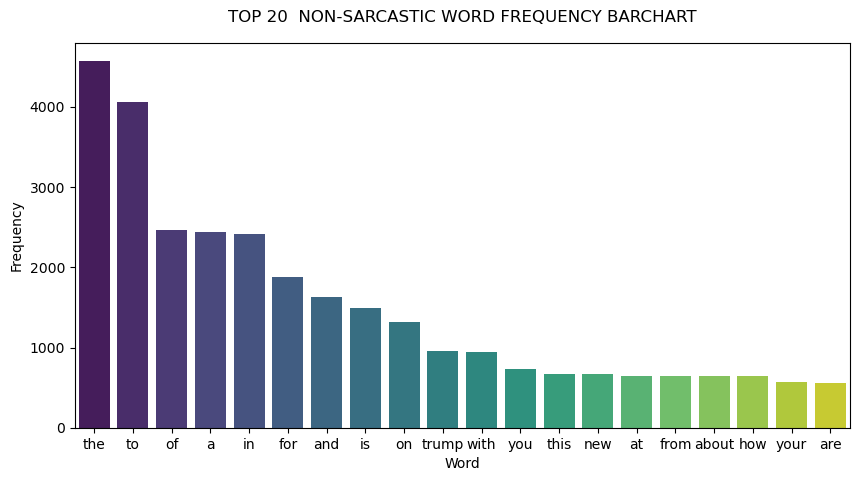

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(no_sar_df,x='Word',y='Frequency',hue='Word',palette='viridis')
plt.title("TOP 20  NON-SARCASTIC WORD FREQUENCY BARCHART",pad=15)
plt.show()

#### PART 3 DATA CLEANING 

In [52]:
import re
import string 

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [53]:
#initilaoze stop words and lemmatizer
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()
import contractions

In [54]:
# Cleaning Function 

In [55]:
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [56]:
def clean_text(text):
    text=text.lower()

    #expand contractions
    text=contractions.fix(text)

    #remove url

    text=re.sub(r'http\S+|www\S+','',text)

    #Punctition Removal
    text=text.translate(str.maketrans('','',string.punctuation))

    # Remove numbers
    text=re.sub(r'\d+','',text)

    #remove extra spaces 
    text= re.sub(r'\s+',' ',text).strip()

    #tokenization
    tokens= word_tokenize(text)

    #stop word removal
    tokens=[word for word in tokens if word not in stop_words]

    #Lemmitization
    tokens=[lemmatizer.lemmatize(word) for word in tokens]
    
    #join text 
    text=" ".join(tokens)

    return text

In [57]:
# Apply this function 

In [58]:
df["clean_headline"]=df["headline"].apply(clean_text)

In [59]:
comparision=pd.DataFrame({"Orignal Headline":df["headline"],"Clean Headline":df["clean_headline"]})
comparision

,Orignal Headline,Clean Headline
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...
...,...,...
28614,jews to celebrate rosh hashasha or something,jew celebrate rosh hashasha something
28615,internal affairs investigator disappointed con...,internal affair investigator disappointed cons...
28616,the most beautiful acceptance speech this week...,beautiful acceptance speech week came queer ko...
28617,mars probe destroyed by orbiting spielberg-gat...,mar probe destroyed orbiting spielberggates sp...


In [60]:
df[["headline","clean_headline","is_sarcastic"]]

,headline,clean_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1
...,...,...,...
28614,jews to celebrate rosh hashasha or something,jew celebrate rosh hashasha something,1
28615,internal affairs investigator disappointed con...,internal affair investigator disappointed cons...,1
28616,the most beautiful acceptance speech this week...,beautiful acceptance speech week came queer ko...,0
28617,mars probe destroyed by orbiting spielberg-gat...,mar probe destroyed orbiting spielberggates sp...,1


#### PART 4 TRAIN TEST SPLIT 

In [61]:
X=df["clean_headline"]
y=df["is_sarcastic"]

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

In [64]:
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

print()

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Samples : (22802,)
Testing Samples  : (5701,)

Training Labels  : (22802,)
Testing Labels   : (5701,)


## PART 4 FEATRUE ENGINEERING 

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [66]:
tfidf= TfidfVectorizer(ngram_range=(1,2),min_df=2,max_features=15000,sublinear_tf=True)

In [67]:
# fit TF-IDF on training data 
X_train_tfidf=tfidf.fit_transform(X_train)

In [68]:
X_test_tfidf=tfidf.transform(X_test)

In [69]:
print("Training IDF SHAPE",X_train_tfidf.shape)
print("TEST IDF SHAPE",X_test_tfidf.shape)

Training IDF SHAPE (22802, 15000)
TEST IDF SHAPE (5701, 15000)


In [70]:
# check vocabulary size

print("Vocabulary_Size :",len(tfidf.vocabulary_))

Vocabulary_Size : 15000


In [71]:
# Featured
features_names= tfidf.get_feature_names_out()
print("Featues_names FIRST 30",features_names[:40])

Featues_names FIRST 30 ['aaron' 'aaron hernandez' 'aarp' 'ab' 'abandon' 'abandoned' 'abandoning'
 'abbas' 'abbey' 'abby' 'abc' 'abdomen' 'abducted' 'abduction' 'abduls'
 'ability' 'able' 'aborted' 'abortion' 'abortion ban' 'abortion clinic'
 'abortion issue' 'abortion law' 'abortion provider' 'abortion right'
 'aboveground' 'abraham' 'abraham lincoln' 'abrams' 'abramson' 'abridged'
 'abroad' 'abruptly' 'absence' 'absolute' 'absolutely'
 'absolutely nothing' 'abu' 'abu dhabi' 'abuse']


In [72]:
print("Feature names Last 30", features_names[-30:])

Feature names Last 30 ['youtube' 'youtube video' 'youtuber' 'yoyo' 'yuletide' 'zachary'
 'zachary quinto' 'zamboni' 'zara' 'zayn' 'zealand' 'zebra' 'zen' 'zero'
 'zero time' 'zeus' 'zika' 'zika virus' 'zimmerman' 'zinke' 'zip' 'zombie'
 'zone' 'zoning' 'zoo' 'zoo animal' 'zookeeper' 'zoologist' 'zuckerberg'
 'zuckerbergs']


In [73]:
type(X_train_tfidf)

scipy.sparse._csr.csr_matrix

In [74]:
# Number of NON ZERO vlaues
print("Non zero train",X_train_tfidf.nnz)
print("Non zero test",X_test_tfidf.nnz)

Non zero train 167763
Non zero test 38623


In [75]:
# lets check matrix sparsity
train_sparsity = 1 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
print("Training Sparsity",round(train_sparsity*100,2),"%")

test_sparsity=1-(X_test_tfidf.nnz/(X_test_tfidf.shape[0]*X_test_tfidf.shape[1]))
print("Test Sparsity",round(test_sparsity*100,2),"%")

Training Sparsity 99.95 %
Test Sparsity 99.95 %


In [76]:
# lets see tf idf representation for first 5 cells 
tfidf_sample=pd.DataFrame(X_train_tfidf[:5].toarray(), columns=tfidf.get_feature_names_out())
display(tfidf_sample)

,aaron,aaron hernandez,aarp,ab,abandon,abandoned,abandoning,abbas,abbey,abby,...,zip,zombie,zone,zoning,zoo,zoo animal,zookeeper,zoologist,zuckerberg,zuckerbergs
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,recall_score)

# PART 5 Machine Learning Models 

In [78]:
# Define Evaluation function 
results=[]
def evaluation (model_name,model,X_train,X_test,y_train,y_test):
    # predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    # ACCURACY
    train_accuracy=accuracy_score(y_train,y_train_pred)
    test_accuracy=accuracy_score(y_test,y_test_pred)

    recall=recall_score(y_test,y_test_pred)

    # print model performance
    print(f"Model Name :{model_name}")
    print(f"Train_Accuracy:{train_accuracy}")
    print(f"Test_Accuracy :{test_accuracy}")
    print(f"Recall_Score :{recall}")

    print("\n Classification Report ")
    print(classification_report(y_test,y_test_pred))

    print("\n Confusion Matrix")
    cm=confusion_matrix(y_test,y_test_pred) 
    
    #display confusion matrix 
    display=ConfusionMatrixDisplay( confusion_matrix=cm,display_labels=["Not Sarcastic","Sarcastic"])

    display.plot()

    plt.title(f"Confusion Matrix - {model_name}")

    plt.show()


    return {"Model":model_name,
            "Train_Accuracy":train_accuracy,
            "Test_Accuracy":test_accuracy,
            "Recall":recall}
            
    

#### 1.Logistic Regression

Model Name :Logistic Regression
Train_Accuracy:0.8846153846153846
Test_Accuracy :0.7847746009472022
Recall_Score :0.7462191073404648

 Classification Report 
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2990
           1       0.79      0.75      0.77      2711

    accuracy                           0.78      5701
   macro avg       0.79      0.78      0.78      5701
weighted avg       0.79      0.78      0.78      5701


 Confusion Matrix


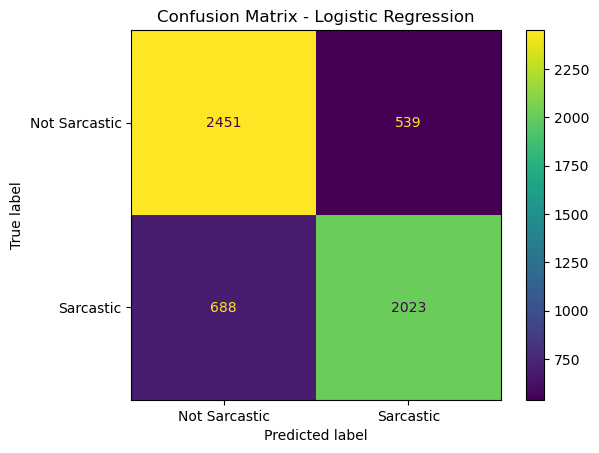

In [84]:
lr_tfidf=LogisticRegression(max_iter=1000,random_state=42)
lr_tfidf.fit(X_train_tfidf,y_train)
lr_result= evaluation("Logistic Regression",lr_tfidf,X_train_tfidf,X_test_tfidf,y_train,y_test)
results.append(lr_result)

#### 2. MULTINOMIAL NAIVE BAYES

Model Name :Multinomial Naive Bayes
Train_Accuracy:0.8894833786509956
Test_Accuracy :0.7886335730573584
Recall_Score :0.7535964588712653

 Classification Report 
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2990
           1       0.79      0.75      0.77      2711

    accuracy                           0.79      5701
   macro avg       0.79      0.79      0.79      5701
weighted avg       0.79      0.79      0.79      5701


 Confusion Matrix


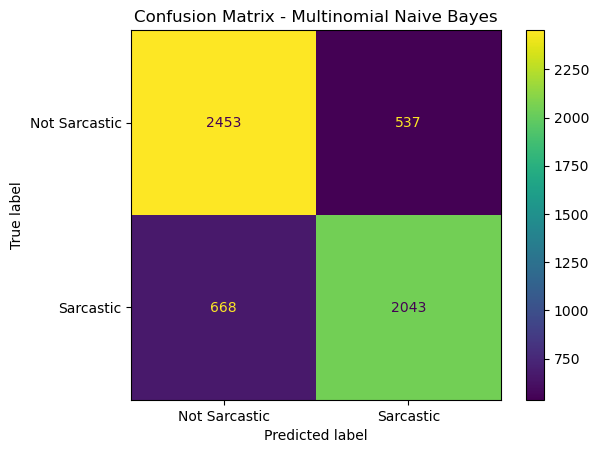

In [85]:
nb_model=MultinomialNB()
nb_model.fit(X_train_tfidf,y_train)
nb_model_result=evaluation("Multinomial Naive Bayes",nb_model,X_train_tfidf,X_test_tfidf,y_train,y_test)
results.append(nb_model_result)

#### 3. LINEAR SVM

Model Name :Linear SVM
Train_Accuracy:0.9562319094816244
Test_Accuracy :0.7888089808805473
Recall_Score :0.7698266322390261

 Classification Report 
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2990
           1       0.78      0.77      0.78      2711

    accuracy                           0.79      5701
   macro avg       0.79      0.79      0.79      5701
weighted avg       0.79      0.79      0.79      5701


 Confusion Matrix


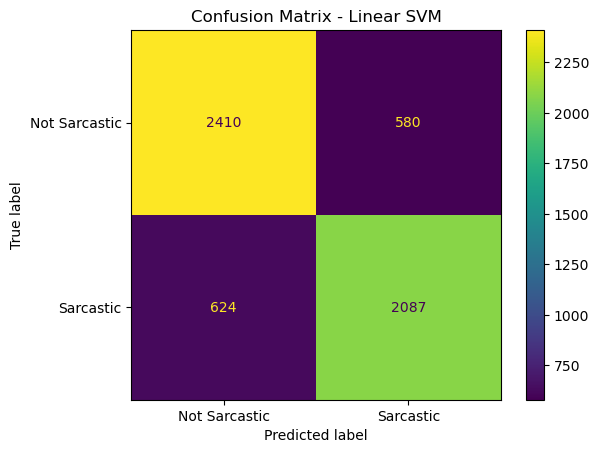

In [87]:


svm_model=LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf,y_train)

svm_model_result=evaluation("Linear SVM",svm_model,X_train_tfidf,X_test_tfidf,y_train,y_test)
results.append(svm_model_result)

#### 4.XGBOOST CLASSIFFIER

Model Name :XGB Classifier
Train_Accuracy:0.7093237435312691
Test_Accuracy :0.6909314155411331
Recall_Score :0.42272224271486536

 Classification Report 
              precision    recall  f1-score   support

           0       0.64      0.93      0.76      2990
           1       0.85      0.42      0.57      2711

    accuracy                           0.69      5701
   macro avg       0.75      0.68      0.66      5701
weighted avg       0.74      0.69      0.67      5701


 Confusion Matrix


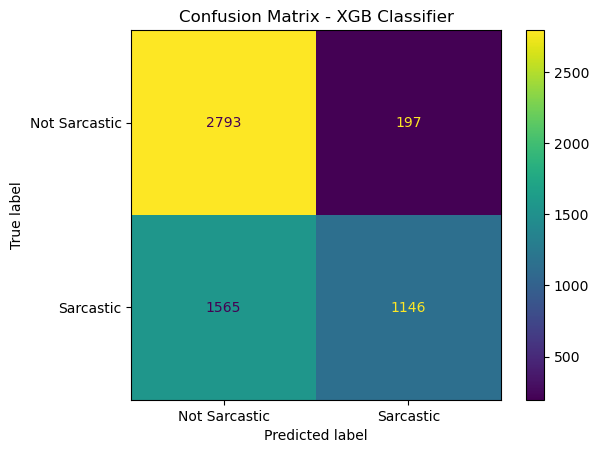

In [88]:
xgb_model=XGBClassifier(objective="binary:logistic",eval_metric="logloss",n_estimator=200,max_depth=6,learning_rate=0.1,random_state=42,n_jobs=-1)

xgb_model.fit(X_train_tfidf,y_train)

xgb_model_result= evaluation("XGB Classifier",xgb_model,X_train_tfidf,X_test_tfidf,y_train,y_test)
results.append(xgb_model_result)

## Comparision Table


In [89]:
result_df=pd.DataFrame(results)
result_df

,Model,Train_Accuracy,Test_Accuracy,Recall
0,Logistic Regression,0.884615,0.784775,0.746219
1,Multinomial Naive Bayes,0.889483,0.788634,0.753596
2,Linear SVM,0.956232,0.788809,0.769827
3,XGB Classifier,0.709324,0.690931,0.422722


# HYPER PARAMETER TUNING 

In [92]:
from sklearn.model_selection import GridSearchCV

In [95]:
svm_model1=LinearSVC(random_state=42)
param_grid={"C":[0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10]}

grid_search_svm=GridSearchCV(estimator=svm_model1,param_grid=param_grid,scoring='recall',cv=5,n_jobs=-1,verbose=1)
grid_search_svm.fit(X_train_tfidf,y_train)
print("Best Parameters",grid_search_svm.best_params_)
print("Best Recall score",grid_search_svm.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters {'C': 0.5}
Best Recall score 0.764505383643048


#### 5. TUNED SVM

Model Name :Tuned SVM
Train_Accuracy:0.9394789930707833
Test_Accuracy :0.7923171373443255
Recall_Score :0.7720398376982663

 Classification Report 
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      2990
           1       0.79      0.77      0.78      2711

    accuracy                           0.79      5701
   macro avg       0.79      0.79      0.79      5701
weighted avg       0.79      0.79      0.79      5701


 Confusion Matrix


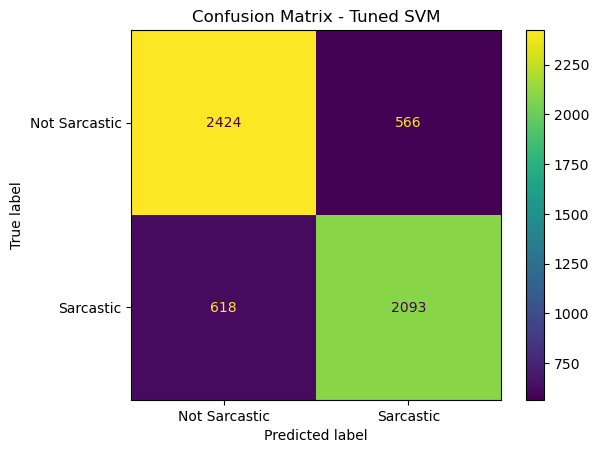

In [79]:
tuned_svm=LinearSVC(C=0.5,random_state=42)
tuned_svm.fit(X_train_tfidf,y_train)

tuned_svm_result=evaluation("Tuned SVM",tuned_svm,X_train_tfidf,X_test_tfidf,y_train,y_test)
results.append(tuned_svm_result)

In [80]:
result_df=pd.DataFrame(results)
result_df

,Model,Train_Accuracy,Test_Accuracy,Recall
0,Tuned SVM,0.939479,0.792317,0.77204


In [81]:
## Futher tuning using LINER SVC AND TFIIDF COMBINATIONS 

In [93]:
from sklearn.pipeline import Pipeline

In [94]:
pipeline = Pipeline([("tfidf", TfidfVectorizer()),("svm", LinearSVC(random_state=42))])

In [95]:
#Parameter Grid

param_grid = {

    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        2,
        3,
        5
    ],

    "tfidf__max_df": [
        0.90,
        0.95
    ],

    "tfidf__sublinear_tf": [
        True,
        False
    ],

    "svm__C": [
        0.2,
        0.3,
        0.4,
        0.5,
        0.6
    ]

}

In [96]:

grid_search1 = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring="recall",

    cv=5,

    n_jobs=-1,

    verbose=2,

    return_train_score=True

)

In [97]:
grid_search1.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.2, 0.3, ...], 'tfidf__max_df': [0.9, 0.95], 'tfidf__min_df': [2, 3, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,input,'content'


In [98]:
print("Best Parameters:")

print(grid_search1.best_params_)


print("\nBest CV Recall:")

print(grid_search1.best_score_)

Best Parameters:
{'svm__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Best CV Recall:
0.7654275100842296


In [99]:
best_pipeline = grid_search1.best_estimator_

Model Name :Tuned TFIDF + Linear SVM
Train_Accuracy:0.9539952635733707
Test_Accuracy :0.7938958077530258
Recall_Score :0.7727775728513464

 Classification Report 
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      2990
           1       0.79      0.77      0.78      2711

    accuracy                           0.79      5701
   macro avg       0.79      0.79      0.79      5701
weighted avg       0.79      0.79      0.79      5701


 Confusion Matrix


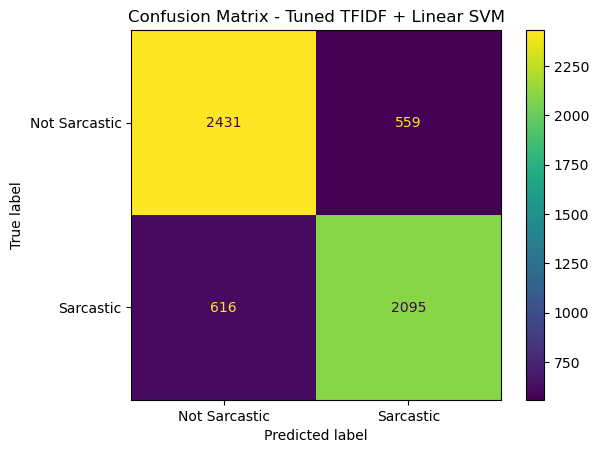

In [100]:
best_pipeline_result_svm=evaluation(
    "Tuned TFIDF + Linear SVM",
    best_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)
results.append(best_pipeline_result_svm)

In [101]:
results_df = pd.DataFrame(results)

results_df

results_df.style.apply(
    lambda row: ["background-color: lightgreen"] * len(row)
    if row.name == 5
    else [""] * len(row),
    axis=1
)

,Model,Train_Accuracy,Test_Accuracy,Recall
0,Tuned SVM,0.939479,0.792317,0.772040
1,Tuned TFIDF + Linear SVM,0.953995,0.793896,0.772778


In [102]:
import joblib

joblib.dump(
    best_pipeline,
    "tuned_tfidf_linear_svm.pkl"
)

['tuned_tfidf_linear_svm.pkl']